# Retail Basket Analysis using Association Rule Mining
### Dataset Variant 7 — Online Retail Dataset (UK E-Commerce, 2010-2011)

**Objective:** Discover frequent itemsets and association rules (using the Apriori algorithm) to understand which products are commonly purchased together. These insights can help with store layout, product bundling, and recommendation systems.

**Dataset columns:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country


## 1. Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load Dataset

In [14]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 3. Data Cleaning & Preprocessing

Steps performed:
- Remove rows with missing `Description`
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with non-positive `Quantity` or `UnitPrice`
- Strip whitespace from product descriptions
- Focus on transactions from the **United Kingdom** (largest subset) to keep computation manageable


In [16]:
# Drop missing descriptions
df = df.dropna(subset=['Description'])

# Remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only positive quantity and price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Clean description text
df['Description'] = df['Description'].str.strip()

# Filter to United Kingdom transactions (largest market)
df = df[df['Country'] == 'United Kingdom']

print("Cleaned shape:", df.shape)
print("Unique invoices:", df['InvoiceNo'].nunique())
print("Unique products:", df['Description'].nunique())

Cleaned shape: (485123, 8)
Unique invoices: 18019
Unique products: 3996


## 4. Exploratory Data Analysis

Let's look at the most frequently purchased products before mining rules.


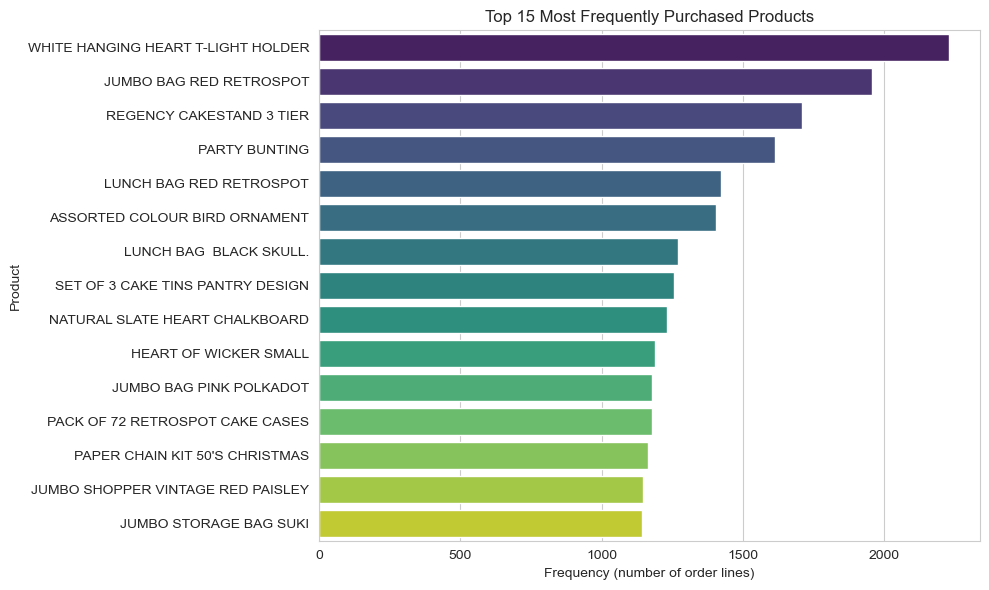

In [17]:
top_items = df['Description'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette='viridis', legend=False)
plt.title('Top 15 Most Frequently Purchased Products')
plt.xlabel('Frequency (number of order lines)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

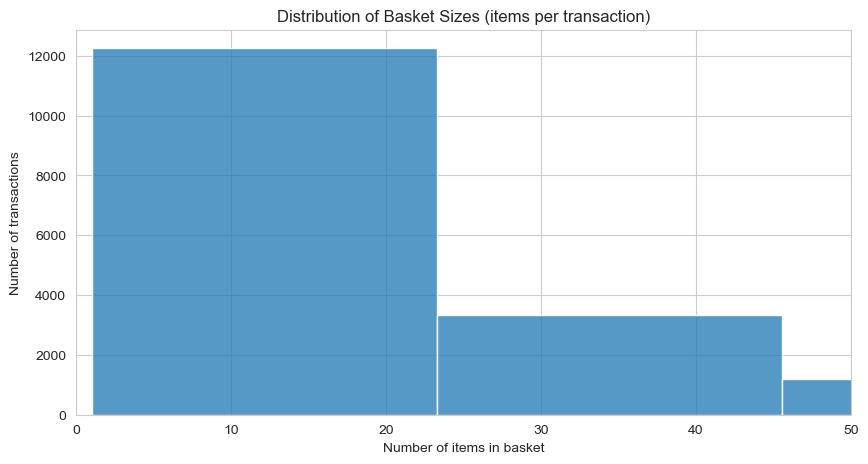

Average basket size: 26.92


In [18]:
# Distribution of basket sizes (items per invoice)
basket_sizes = df.groupby('InvoiceNo')['StockCode'].count()

plt.figure(figsize=(10,5))
sns.histplot(basket_sizes, bins=50, kde=False)
plt.title('Distribution of Basket Sizes (items per transaction)')
plt.xlabel('Number of items in basket')
plt.ylabel('Number of transactions')
plt.xlim(0, 50)
plt.show()

print("Average basket size:", round(basket_sizes.mean(), 2))

## 5. Create Transaction Baskets

To run Apriori, we need each transaction (InvoiceNo) represented as a **set of items purchased**.

To keep the algorithm computationally feasible, we will:
- Limit analysis to the **top 100 most popular products**
- Build a list of "baskets" (one per invoice, containing the products bought)


In [19]:
# Select top N popular products to limit dimensionality
TOP_N = 100
top_products = df['Description'].value_counts().head(TOP_N).index.tolist()

df_filtered = df[df['Description'].isin(top_products)]

# Group items by invoice -> list of products bought together
basket = df_filtered.groupby('InvoiceNo')['Description'].apply(lambda x: list(set(x)))

# Remove baskets with fewer than 2 items (no association possible)
basket = basket[basket.apply(len) >= 2]

print("Number of transactions used:", len(basket))
basket.head()

Number of transactions used: 11624


InvoiceNo
536367    [HOME BUILDING BLOCK WORD, LOVE BUILDING BLOCK...
536373    [WOODEN FRAME ANTIQUE WHITE, WHITE HANGING HEA...
536375    [WOODEN FRAME ANTIQUE WHITE, WHITE HANGING HEA...
536378    [JUMBO STORAGE BAG SUKI, PACK OF 72 RETROSPOT ...
536381    [PAPER CHAIN KIT 50'S CHRISTMAS, RETROSPOT TEA...
Name: Description, dtype: object

## 6. Apriori Algorithm (Frequent Itemset Mining)

We implement the **Apriori algorithm** from scratch:

1. Calculate **support** for each itemset = (transactions containing itemset) / (total transactions)
2. Generate itemsets of size 1, then iteratively build larger itemsets, pruning those below `min_support`
3. From frequent itemsets, generate **association rules** and compute **confidence** and **lift**

**Metrics:**
- **Support(A)** = freq(A) / N
- **Confidence(A -> B)** = Support(A union B) / Support(A)
- **Lift(A -> B)** = Confidence(A -> B) / Support(B)


In [20]:
def get_frequent_itemsets(transactions, min_support):
    N = len(transactions)
    item_counts = defaultdict(int)

    # Count single items
    for t in transactions:
        for item in t:
            item_counts[frozenset([item])] += 1

    freq_itemsets = {}
    current_itemsets = {iset: cnt for iset, cnt in item_counts.items() if cnt / N >= min_support}
    freq_itemsets.update(current_itemsets)

    k = 2
    while current_itemsets:
        candidates = defaultdict(int)
        prev_sets = list(current_itemsets.keys())
        for i in range(len(prev_sets)):
            for j in range(i+1, len(prev_sets)):
                union = prev_sets[i] | prev_sets[j]
                if len(union) == k:
                    candidates[union] = 0

        # Count support of candidates
        for t in transactions:
            t_set = set(t)
            for cand in candidates:
                if cand.issubset(t_set):
                    candidates[cand] += 1

        current_itemsets = {iset: cnt for iset, cnt in candidates.items() if cnt / N >= min_support}
        freq_itemsets.update(current_itemsets)
        k += 1

    return freq_itemsets, N


transactions = basket.tolist()
MIN_SUPPORT = 0.02   # itemset must appear in at least 2% of transactions

freq_itemsets, N = get_frequent_itemsets(transactions, MIN_SUPPORT)
print(f"Total transactions: {N}")
print(f"Number of frequent itemsets found: {len(freq_itemsets)}")

Total transactions: 11624
Number of frequent itemsets found: 522


In [21]:
# Display top frequent itemsets by support
freq_df = pd.DataFrame([
    {'itemset': set(iset), 'size': len(iset), 'support': cnt / N}
    for iset, cnt in freq_itemsets.items()
]).sort_values('support', ascending=False).reset_index(drop=True)

freq_df.head(15)

,itemset,size,support
0,{WHITE HANGING HEART T-LIGHT HOLDER},1,0.176703
1,{JUMBO BAG RED RETROSPOT},1,0.163541
2,{REGENCY CAKESTAND 3 TIER},1,0.134119
3,{PARTY BUNTING},1,0.128183
4,{LUNCH BAG RED RETROSPOT},1,0.118978
5,{ASSORTED COLOUR BIRD ORNAMENT},1,0.109515
6,{LUNCH BAG BLACK SKULL.},1,0.103579
7,{SET OF 3 CAKE TINS PANTRY DESIGN},1,0.103063
8,{NATURAL SLATE HEART CHALKBOARD},1,0.099880
9,{JUMBO BAG PINK POLKADOT},1,0.098589


## 7. Generate Association Rules

For every frequent itemset of size >= 2, generate all possible rules `A -> B`
and calculate confidence and lift. We then filter rules using a minimum confidence threshold.


In [22]:
MIN_CONFIDENCE = 0.3

rules = []
for itemset, cnt in freq_itemsets.items():
    if len(itemset) < 2:
        continue
    itemset_support = cnt / N
    for i in range(1, len(itemset)):
        for antecedent in combinations(itemset, i):
            antecedent = frozenset(antecedent)
            consequent = itemset - antecedent
            if antecedent in freq_itemsets:
                ant_support = freq_itemsets[antecedent] / N
                confidence = itemset_support / ant_support
                if confidence >= MIN_CONFIDENCE:
                    cons_support = freq_itemsets.get(consequent, 0) / N if consequent in freq_itemsets else None
                    lift = confidence / cons_support if cons_support else None
                    rules.append({
                        'antecedent': set(antecedent),
                        'consequent': set(consequent),
                        'support': itemset_support,
                        'confidence': confidence,
                        'lift': lift
                    })

rules_df = pd.DataFrame(rules).dropna(subset=['lift']).sort_values('lift', ascending=False).reset_index(drop=True)
print(f"Total rules generated: {len(rules_df)}")
rules_df.head(15)

Total rules generated: 773


,antecedent,consequent,support,confidence,lift
0,"{WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOT...","{STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG SUKI ...",0.021421,0.579070,17.127499
1,"{STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG SUKI ...","{WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOT...",0.021421,0.633588,17.127499
2,"{CHARLOTTE BAG PINK POLKADOT, CHARLOTTE BAG SU...","{WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOT...",0.020647,0.625000,16.895349
3,"{WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOT...","{CHARLOTTE BAG PINK POLKADOT, CHARLOTTE BAG SU...",0.020647,0.558140,16.895349
4,"{CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHAR...","{CHARLOTTE BAG PINK POLKADOT, WOODLAND CHARLOT...",0.020647,0.505263,16.451482
5,"{CHARLOTTE BAG PINK POLKADOT, WOODLAND CHARLOT...","{CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHAR...",0.020647,0.672269,16.451482
6,"{WOODLAND CHARLOTTE BAG, STRAWBERRY CHARLOTTE ...","{CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHAR...",0.021421,0.665775,16.292575
7,"{CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHAR...","{WOODLAND CHARLOTTE BAG, STRAWBERRY CHARLOTTE ...",0.021421,0.524211,16.292575
8,"{CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHAR...","{CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...",0.020475,0.501053,16.089049
9,"{CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...","{CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHAR...",0.020475,0.657459,16.089049


## 8. Visualize Top Association Rules

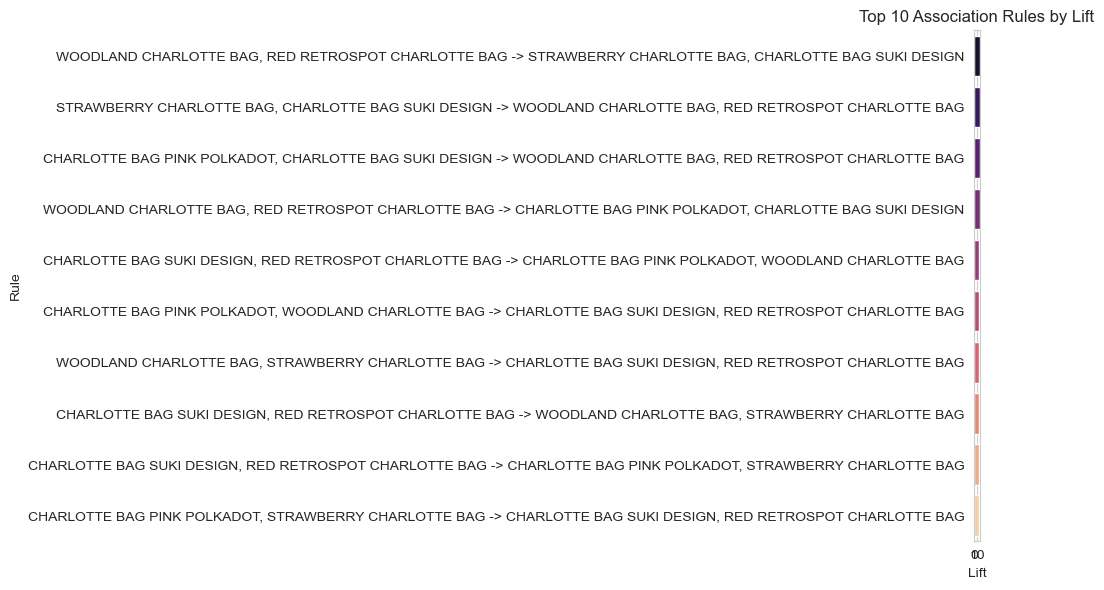

In [23]:
top_rules = rules_df.head(10).copy()
top_rules['rule'] = top_rules.apply(
    lambda r: ', '.join(r['antecedent']) + ' -> ' + ', '.join(r['consequent']), axis=1
)

plt.figure(figsize=(10,6))
sns.barplot(x='lift', y='rule', data=top_rules, hue='rule', palette='magma', legend=False)
plt.title('Top 10 Association Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('Rule')
plt.tight_layout()
plt.show()

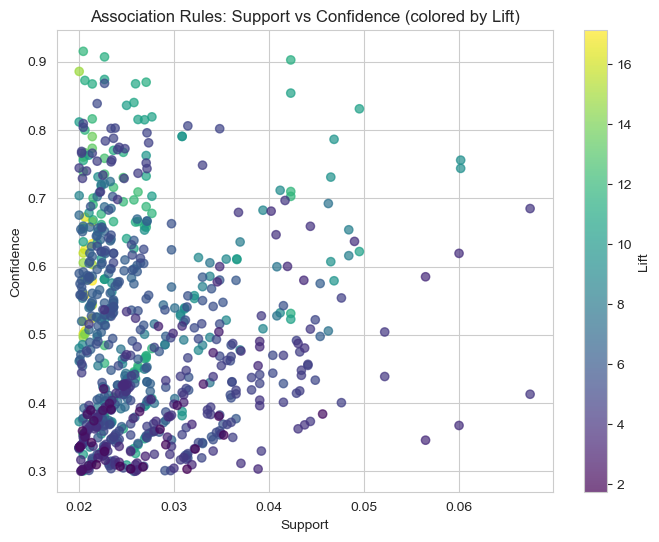

In [24]:
# Scatter plot: Support vs Confidence, colored by Lift
plt.figure(figsize=(8,6))
sc = plt.scatter(rules_df['support'], rules_df['confidence'], c=rules_df['lift'], cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (colored by Lift)')
plt.show()

## 9. Business Insights & Conclusions

Based on the generated association rules:

- Rules with **high lift (> 1)** indicate strong positive relationships -- these item pairs are bought together far more often than chance would suggest.
- These products can be:
  - Placed near each other in store layout
  - Bundled together as combo offers
  - Recommended together in the "frequently bought with" section of an online store

**Example interpretation:** If `A -> B` has confidence 0.6 and lift 3.5, it means customers who buy A are 60% likely to also buy B, and this combination occurs 3.5x more often than if A and B were independent -- a strong cross-selling opportunity.

### Possible Extensions
- Try different `MIN_SUPPORT` / `MIN_CONFIDENCE` thresholds to find more/fewer rules
- Repeat the analysis for other countries
- Use FP-Growth for faster computation on larger datasets
- Build a simple recommendation function using the rules table
